<a href="https://colab.research.google.com/github/Priya-Rathor/Machine-learning/blob/main/batch_vs_stochastic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import time

In [5]:
import os
print(os.listdir())


['.config', '.ipynb_checkpoints', 'Social_Network_Ads .csv', 'sample_data']


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df = pd.read_csv('Social_Network_Ads .csv')

In [10]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [11]:
df = df[['Age','EstimatedSalary','Purchased']]

In [12]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [13]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [16]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time
history = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)
#end = time.time()-start

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6819 - loss: 0.6172 - val_accuracy: 0.3625 - val_loss: 0.7174
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7121 - loss: 0.4467 - val_accuracy: 0.6125 - val_loss: 0.6246
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7992 - loss: 0.3670 - val_accuracy: 0.7250 - val_loss: 0.5567
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.3367 - val_accuracy: 0.8000 - val_loss: 0.4867
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8487 - loss: 0.3323 - val_accuracy: 0.8750 - val_loss: 0.4316
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8485 - loss: 0.3094 - val_accuracy: 0.8750 - val_loss: 0.3911
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8305 - loss: 0.3192 - val_accuracy: 0.9000 - val_loss: 0.3447
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8671 - loss: 0.2926 - val_accu

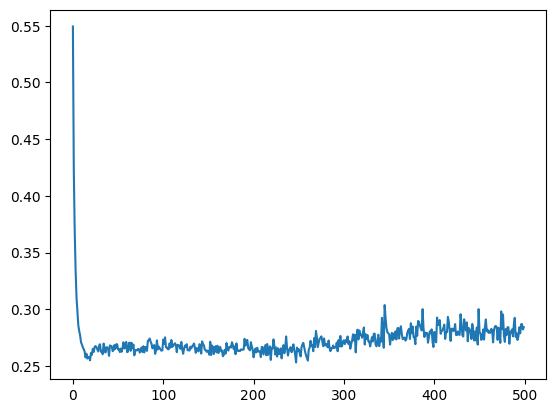

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])


In [20]:
## Stochastic GD
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#end = time.time()-start

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.7911 - loss: 0.6093 - val_accuracy: 0.5375 - val_loss: 0.6744
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8110 - loss: 0.6000 - val_accuracy: 0.5500 - val_loss: 0.6699
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8218 - loss: 0.5916 - val_accuracy: 0.5625 - val_loss: 0.6653
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8173 - loss: 0.5899 - val_accuracy: 0.5625 - val_loss: 0.6636
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8239 - loss: 0.5814 - val_accuracy: 0.5875 - val_loss: 0.6609
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8214 - loss: 0.5796 - val_accuracy: 0.5875 - val_loss: 0.6581
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8315 - loss: 0.5739 - val_accuracy: 0.6125 - val_loss: 0.6557
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8370 - loss: 0.5685 - val_accuracy: 0.6375 - val_loss: 0.65

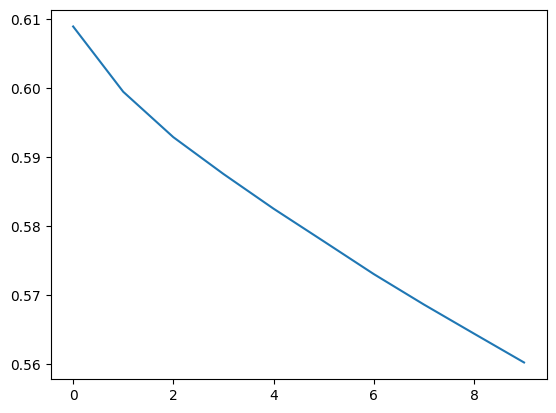

In [22]:
plt.plot(history.history['loss'])